In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Input: Lookback period in months
lookback_months = 12
lookback_days = 300 #days

# Fetch data
meal_data = yf.download("ZM=F", period=f"{lookback_days}d", interval="1d")
oil_data = yf.download("ZL=F", period=f"{lookback_days}d", interval="1d")
bean_data = yf.download("ZS=F", period=f"{lookback_days}d", interval="1d")




[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [5]:
meal_data.columns = ['_'.join(col) for col in meal_data.columns]
oil_data.columns = ['_'.join(col) for col in oil_data.columns]
bean_data.columns = ['_'.join(col) for col in bean_data.columns]



In [6]:
oil_data.rename(columns = {'Close_ZL=F' : 'Close'}, inplace=True )
meal_data.rename(columns = {'Close_ZM=F' : 'Close'}, inplace=True )
bean_data.rename(columns= {'Close_ZS=F' : 'Close'}, inplace=True)

In [8]:
meal_data

,Close,High_ZM=F,Low_ZM=F,Open_ZM=F,Volume_ZM=F
Date,,,,,
2025-01-13,300.200012,300.200012,296.700012,296.700012,63
2025-01-14,298.399994,298.399994,298.399994,298.399994,71873
2025-01-15,302.000000,309.299988,301.399994,305.500000,60603
2025-01-16,294.399994,302.000000,293.500000,301.799988,86235
2025-01-17,297.200012,299.299988,294.100006,295.500000,64775
...,...,...,...,...,...
2025-12-26,303.700012,307.899994,303.000000,305.799988,25113
2025-12-29,298.799988,305.000000,298.200012,304.200012,29749
2025-12-30,296.700012,300.000000,295.299988,298.799988,8433


In [9]:
# Merge and clean
meal_data = meal_data['Close']
oil_data = oil_data['Close']
bean_data = bean_data['Close']



📊 SB/SBO Spread Analysis
Current SB/SBO Ratio: 21.212
12-Month Mean Ratio: 21.197
Z-Score: 0.01
SB Contract Notional: $52,287.50
SBO Contract Notional: $29,580.00
Risk Parity Float Ratio (SB:SBO): 1.768
Rounded Contract Ratio: 1 SBM : 1 SBO


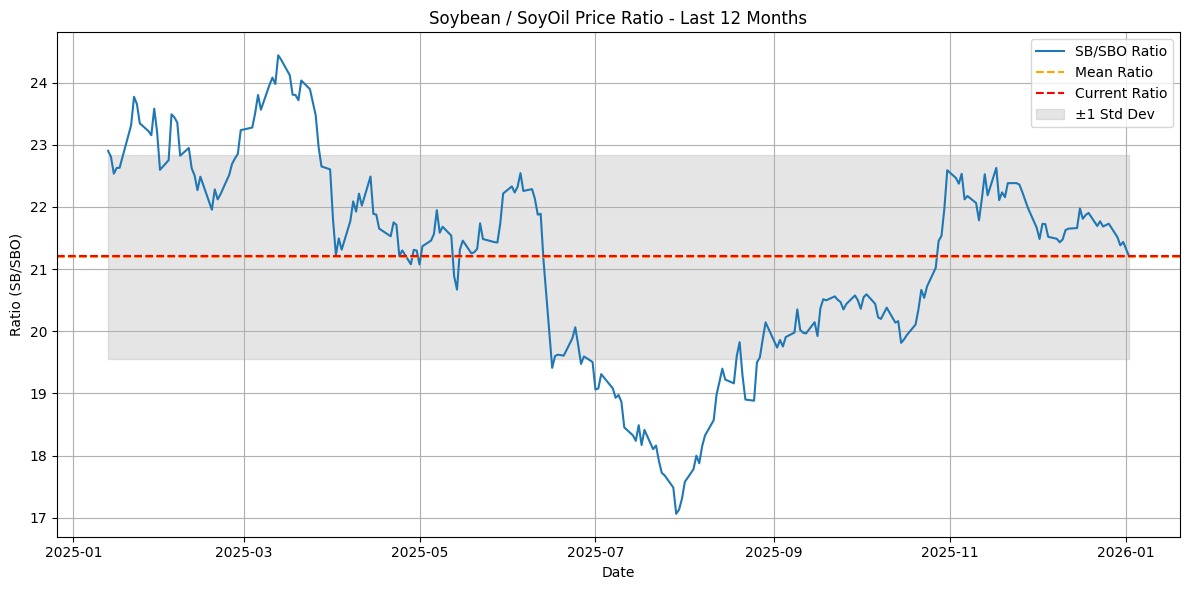

In [10]:

data = pd.DataFrame({
    'Meal': meal_data,
    'Oil': oil_data,
    'Bean' : bean_data
}).dropna()

# Calculate ratio and statistics
data['Ratio'] = data['Bean'] / data['Oil']
current_ratio = data['Ratio'].iloc[-1]
mean_ratio = data['Ratio'].mean()
std_ratio = data['Ratio'].std()
z_score = (current_ratio - mean_ratio) / std_ratio

# Calculate contract notional values
bean_contract_value = data['Bean'].iloc[-1] * 5000 / 100   # 5000 bushels
oil_contract_value = data['Oil'].iloc[-1] * 60000 /100     # 60,000 lbs

# Ratio of values
float_ratio = bean_contract_value / oil_contract_value
rounded_ratio = (1, round(oil_contract_value / bean_contract_value))

# Print summary
print("\n📊 SB/SBO Spread Analysis")
print(f"Current SB/SBO Ratio: {current_ratio:.3f}")
print(f"12-Month Mean Ratio: {mean_ratio:.3f}")
print(f"Z-Score: {z_score:.2f}")
print(f"SB Contract Notional: ${bean_contract_value:,.2f}")
print(f"SBO Contract Notional: ${oil_contract_value:,.2f}")
print(f"Risk Parity Float Ratio (SB:SBO): {float_ratio:.3f}")
print(f"Rounded Contract Ratio: {rounded_ratio[0]} SBM : {rounded_ratio[1]} SBO")

# Plot
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Ratio'], label='SB/SBO Ratio')
plt.axhline(mean_ratio, color='orange', linestyle='--', label='Mean Ratio')
plt.axhline(current_ratio, color='red', linestyle='--', label='Current Ratio')
plt.fill_between(data.index, mean_ratio - std_ratio, mean_ratio + std_ratio,
                 color='gray', alpha=0.2, label='±1 Std Dev')
plt.title(f"Soybean / SoyOil Price Ratio - Last {lookback_months} Months")
plt.xlabel("Date")
plt.ylabel("Ratio (SB/SBO)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
